In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

In [ ]:
# STEP 2 — Load & Normalize CIFAR-10
(x_train,y_train),(x_test,y_test)=keras.datasets.cifar10.load_data()

x_train=x_train/255
x_test=x_test/255

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [ ]:
# STEP 3 — Strong Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
# STEP 4 — Build a Strong CNN Architecture

model=models.Sequential([
    # block1
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # block2
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # block3
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # classifier
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# STEP 5 — Compile with Strong Optimizer

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [ ]:
# STEP 6 — Add Powerful Callbacks

callbacks=[
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',patience=10,restore_best_weights=True),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',factor=0.5,patience=5)
]

In [ ]:
# STEP 7 — Train with Augmentation

history=model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=10,
    validation_data=(x_test,y_test),
    callbacks=callbacks
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7411 - loss: 0.7431 - val_accuracy: 0.7677 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7542 - loss: 0.7034 - val_accuracy: 0.7621 - val_loss: 0.7136 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7671 - loss: 0.6724 - val_accuracy: 0.7768 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.7782 - loss: 0.6396 - val_accuracy: 0.7833 - val_loss: 0.6493 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7858 - loss: 0.6185 - val_accuracy: 0.7745 - val_loss: 0.6842 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.7942 - loss: 0.5986 - val_accuracy: 0.7925 - val_loss: 0.6240 - learning_rate: 0.0010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7981 - l

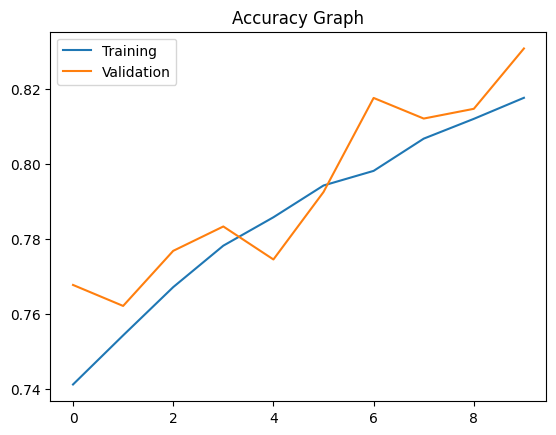

In [ ]:
# STEP 8- plot accuracy and loss

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training','Validation'])
plt.title('Accuracy Graph')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


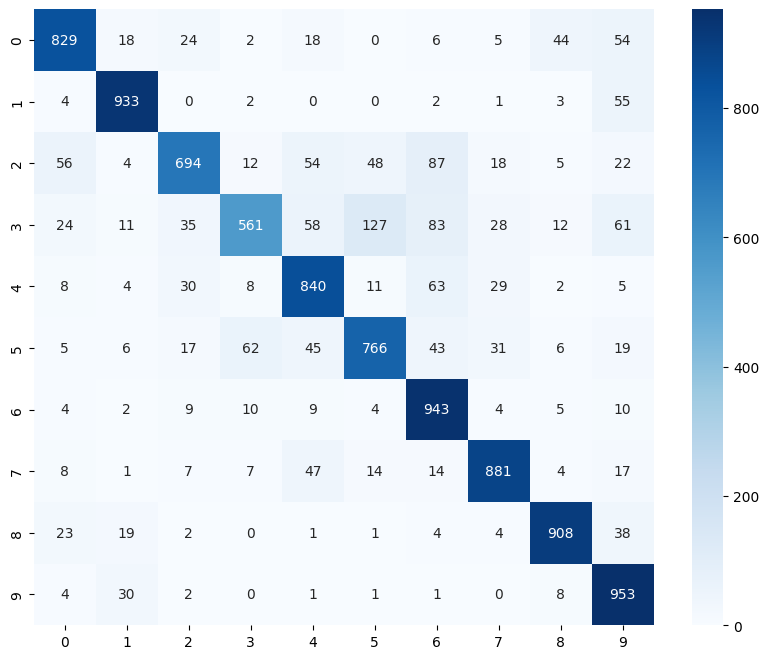

In [ ]:
# STEP 9 — Confusion Matrix

y_pred=model.predict(x_test)
y_pred=np.argmax(y_pred,axis=1)

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.show()

In [ ]:
model.save("cifar10_cnn_model.h5")

In [ ]:
import cv2
img=cv2.imread('/content/test_img.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img=cv2.resize(img,(32,32))
img=img/255.0  # normalization
img=np.expand_dims(img,axis=0) # make it (1,32,32,3)

In [ ]:
y_pred=model.predict(img)
y_pred=np.argmax(y_pred)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3


In [ ]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [ ]:
print("Predictions:",classes[y_pred])

Predictions: cat
